
📊 AUC Score: 0.65

📊 ROC Table:

        FPR  TPR
0  0.000000  0.0
1  0.000004  0.0
2  0.000031  0.0
3  0.000045  0.0
4  0.000049  0.0


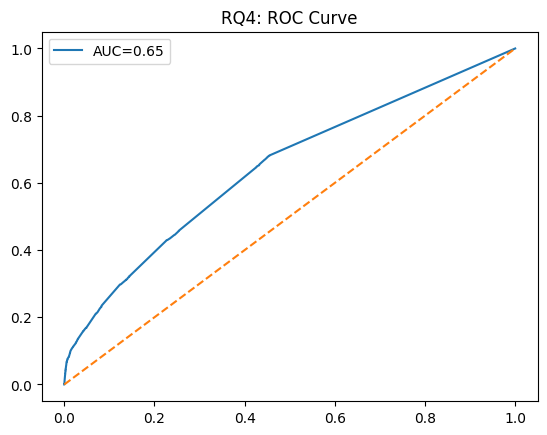

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/tracks.csv")
# First, select only numeric columns
df = df.select_dtypes(include="number")
# Then, fill NaN values in these numeric columns with their respective medians
df = df.fillna(df.median())

df["hit"] = (df["popularity"] >= 70).astype(int)

X = df.drop(["popularity","hit"], axis=1)
y = df["hit"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

print(f"\n📊 AUC Score: {roc_auc:.2f}")

roc_df = pd.DataFrame({"FPR":fpr, "TPR":tpr})
print("\n📊 ROC Table:\n")
print(roc_df.head())

roc_df.to_csv("RQ4_roc_data.csv", index=False)

# Plot
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("RQ4: ROC Curve")

plt.savefig("RQ4_roc.pdf")
plt.show()